# 异常点检测：基于密度聚类（DBSCAN）的实验


## 知识点简介
密度聚类是一类不依赖簇形状假设的聚类方法，其中 **DBSCAN**（Density-Based Spatial Clustering of Applications with Noise）通过“密度可达”概念，把高密度区域聚为簇，并将低密度区域的样本标记为噪声（异常点）。

## 为什么用密度聚类做异常点检测
- **异常定义自然**：低密度区域样本可直接视为噪声（异常点）。
- **无需预设簇数**：真实数据中簇数常未知，DBSCAN 能自动发现。
- **适配任意形状簇**：对非球形簇也能较好识别，适合复杂场景。

接下来我们将：
1. 生成示例数据（含异常点）。
2. 用 DBSCAN 进行聚类并识别异常点。
3. 输出必要的中间结果并进行可视化。
4. 进行参数敏感性分析。
5. 给出拓展与思考题及解题思路。

## 1. 环境准备与库导入

下面导入本案例所需的库，并设置随机种子以保证结果可复现。

In [25]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# 隐藏常见警告（如需要可按需调整过滤级别）
warnings.filterwarnings("ignore")

np.random.seed(42)
sns.set(style="whitegrid", font="sans-serif", rc={"figure.figsize": (7, 5)})

# 解决中文显示问题（按优先级选择本机可用字体）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("Libraries loaded.")

Libraries loaded.


## 2. 生成示例数据（含异常点）

我们使用 `make_blobs` 生成两个密度较高的簇，再额外加入一批均匀分布的“异常点”，并保留真实标签用于对比。

In [26]:
# 生成两个簇
X_inliers, y_inliers = make_blobs(
    n_samples=400,
    centers=[(-2, -2), (3, 3)],
    cluster_std=[0.8, 0.9],
    random_state=42
)

# 生成异常点（均匀分布）
num_outliers = 30
X_outliers = np.random.uniform(low=-6, high=7, size=(num_outliers, 2))

# 合并数据
X = np.vstack([X_inliers, X_outliers])

# 真实标签：正常点为 0，异常点为 1（仅用于教学对比）
y_true = np.hstack([
    np.zeros(len(X_inliers), dtype=int),
    np.ones(num_outliers, dtype=int)
])

# 放入 DataFrame 便于查看
df = pd.DataFrame(X, columns=["x1", "x2"])
df["is_outlier_true"] = y_true

print("数据规模：", df.shape)
print("异常点数量（真实）：", df["is_outlier_true"].sum())
print(df.head())

数据规模： (430, 3)
异常点数量（真实）： 30
         x1        x2  is_outlier_true
0  3.304647  2.626241                0
1  2.594941  3.560565                0
2  2.529549  3.944108                0
3  3.025487  3.026781                0
4  2.109356  2.886792                0


## 3. 数据可视化（原始数据）

先看看原始点的分布情况，为后面理解“密度”做准备。

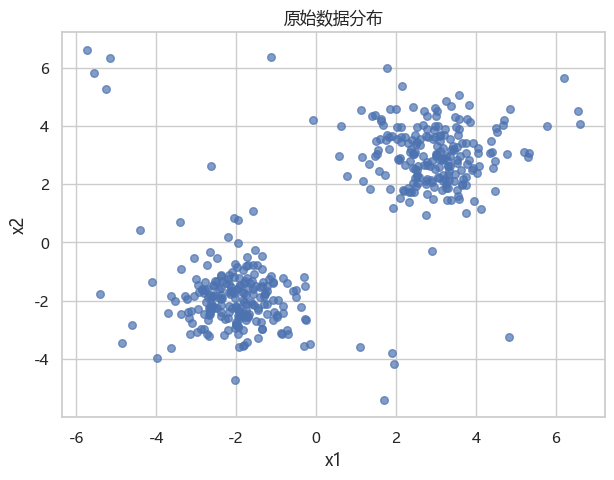

In [27]:
plt.scatter(df["x1"], df["x2"], s=30, alpha=0.7)
plt.title("原始数据分布")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 4. 估计 $\varepsilon$（eps）的一个常用方法：k-距离图

DBSCAN 中 `eps` 是邻域半径，`min_samples` 是核心点最少邻居数。常用做法是绘制 *k-距离图*，观察“拐点”位置。下面以 $k=4$ 为例。

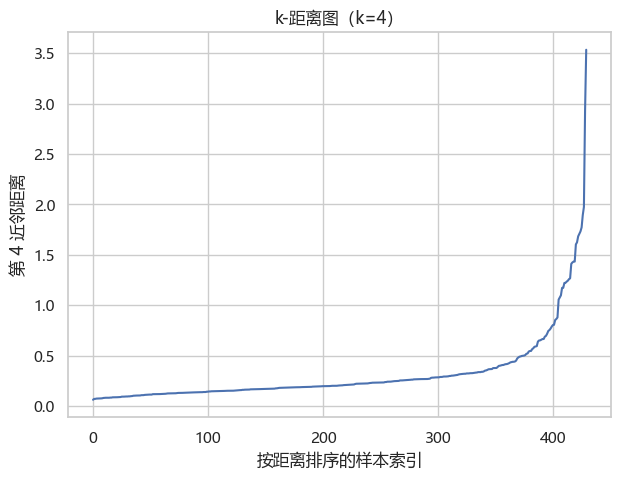

k-距离统计：
count    430.000000
mean       0.322518
std        0.368932
min        0.065114
25%        0.149931
50%        0.206638
75%        0.321638
max        3.533156
dtype: float64


In [28]:
k = 4
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)

distances, _ = nn.kneighbors(X)
# 取第 k 个近邻的距离（按距离从小到大排序）
k_distances = np.sort(distances[:, k-1])

plt.plot(k_distances)
plt.title("k-距离图（k=4）")
plt.xlabel("按距离排序的样本索引")
plt.ylabel("第 4 近邻距离")
plt.show()

print("k-距离统计：")
print(pd.Series(k_distances).describe())

## 5. 运行 DBSCAN 并识别异常点

在 DBSCAN 中，**标签为 -1 的点即被判为噪声（异常点）**。我们先用一个合理的 `eps` 和 `min_samples` 试运行。

In [29]:
eps = 0.8
min_samples = 5

model = DBSCAN(eps=eps, min_samples=min_samples)
labels = model.fit_predict(X)

df["cluster_label"] = labels
df["is_outlier_dbscan"] = (labels == -1).astype(int)

print("DBSCAN 参数：", {"eps": eps, "min_samples": min_samples})
print("簇标签分布：")
print(df["cluster_label"].value_counts().sort_index())
print("检测到的异常点数量：", df["is_outlier_dbscan"].sum())

DBSCAN 参数： {'eps': 0.8, 'min_samples': 5}
簇标签分布：
cluster_label
-1     25
 0    201
 1    204
Name: count, dtype: int64
检测到的异常点数量： 25


## 6. 可视化聚类结果与异常点

用不同颜色标记簇，噪声点用红色边框突出显示。

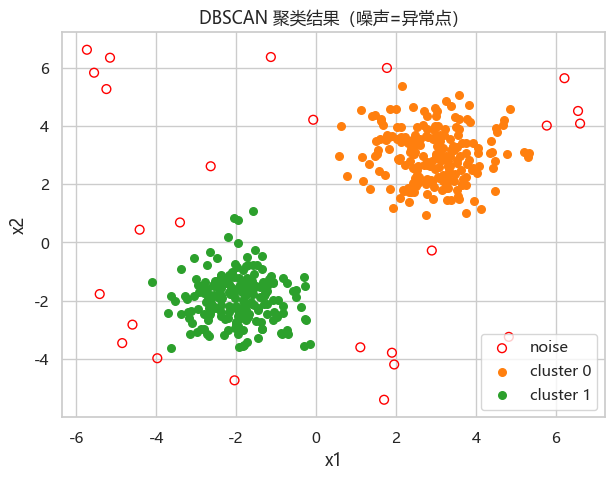

In [30]:
plt.figure(figsize=(7, 5))
unique_labels = sorted(df["cluster_label"].unique())
palette = sns.color_palette("tab10", n_colors=max(len(unique_labels), 3))

for idx, lab in enumerate(unique_labels):
    subset = df[df["cluster_label"] == lab]
    if lab == -1:
        plt.scatter(subset["x1"], subset["x2"], s=40, c="none", edgecolors="red", label="noise")
    else:
        plt.scatter(subset["x1"], subset["x2"], s=30, color=palette[idx % len(palette)], label=f"cluster {lab}")

plt.title("DBSCAN 聚类结果（噪声=异常点）")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

## 7. 与真实标签对比

在真实任务中通常没有异常点标签，本节仅用于教学对比 DBSCAN 的识别效果。

In [31]:
ct = pd.crosstab(df["is_outlier_true"], df["is_outlier_dbscan"],
                rownames=["真实异常"], colnames=["DBSCAN异常"], dropna=False)
print("交叉表：")
print(ct)

precision = ct.loc[1, 1] / max(ct[1].sum(), 1)
recall = ct.loc[1, 1] / max(ct.loc[1].sum(), 1)
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

交叉表：
DBSCAN异常    0   1
真实异常             
0         398   2
1           7  23
Precision: 0.920
Recall: 0.767


## 8. 参数敏感性（eps）简要观察

`eps` 变化会显著影响簇数量与异常点数量。下面做一个小范围扫参，观察趋势。

In [32]:
eps_list = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
rows = []

for e in eps_list:
    labels_tmp = DBSCAN(eps=e, min_samples=min_samples).fit_predict(X)
    n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_outliers = np.sum(labels_tmp == -1)
    rows.append({"eps": e, "clusters": n_clusters, "outliers": n_outliers})

param_df = pd.DataFrame(rows)
print(param_df)

   eps  clusters  outliers
0  0.5         2        48
1  0.6         2        37
2  0.7         2        28
3  0.8         2        25
4  0.9         2        24
5  1.0         2        21


## 9. 小结

- DBSCAN 不需要预先指定簇数，能自然识别噪声点。
- `eps` 与 `min_samples` 是关键参数，可借助 k-距离图进行初步估计。
- 当数据密度差异较大时，DBSCAN 可能会把稀疏簇误判为异常点。

---

## 10. 拓展与思考（含解题思路）

1. **如果簇的密度差异很大，DBSCAN 可能失败吗？如何改进？**  
   **思路**：DBSCAN 使用单一 `eps`，对不同密度簇不够友好。可尝试 **OPTICS** 或 **HDBSCAN** 这类可变密度方法。

2. **如何在高维数据中选择 `eps`？**  
   **思路**：高维下距离分布趋于集中，可考虑：
   - 先做降维（PCA、UMAP）再运行 DBSCAN；
   - 使用基于局部密度的异常检测（如 LOF）进行对比。

3. **用真实数据集进行练习**：例如网络入侵检测或信用卡欺诈数据。  
   **思路**：先做数据清洗与标准化，再用 DBSCAN 进行初步异常点筛查，最后与业务规则结合。

4. **试着将异常点检测结果转化为业务指标**：如异常率、异常分布漂移。  
   **思路**：按时间窗口统计异常率，观察是否出现显著变化，并与阈值或告警策略联动。